# Unit 5: mne-sample-data 完整流程综合案例

## 概述

本单元整合前四个单元的知识，使用 **mne-sample-data** 数据集完成从原始数据加载到ERP和时频分析的完整EEG数据处理流程。

## 数据集说明

**mne-sample-data** 包含：
- 一名受试者的MEG/EEG联合记录
- 听觉和视觉诱发的oddball实验范式
- 四种实验条件：
  - Auditory Left (左耳听觉刺激)
  - Auditory Right (右耳听觉刺激)
  - Visual Left (左侧视野视觉刺激)
  - Visual Right (右侧视野视觉刺激)

## 完整分析流程

```text
1. 数据加载
   ↓
2. 数据探索与质量控制
   ↓
3. 预处理
   ├── 滤波
   ├── 重参考
   ├── 坏道检测与插值
   └── ICA去伪迹
   ↓
4. Epoch提取与基线校正
   ↓
5. 伪迹拒绝
   ↓
6. ERP分析
   ├── Evoked计算
   ├── 成分测量
   ├── 可视化
   └── 统计检验
   ↓
7. 时频分析
   ├── Morlet小波变换
   ├── 基线校正
   └── ERS/ERD可视化
   ↓
8. 结果报告
```


## 实践代码

In [14]:
# 导入所有必要的库
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import find_peaks
from mne.preprocessing import ICA
from mne.time_frequency import tfr_morlet
import pandas as pd

# 设置MNE日志级别
mne.set_log_level('WARNING')

# 设置绘图风格
plt.style.use('default')

print("=" * 60)
print("Unit 5: mne-sample-data 完整流程综合案例")
print("=" * 60)

Unit 5: mne-sample-data 完整流程综合案例


### 阶段 1: 数据加载与探索

In [6]:
# 1.1 加载mne-sample-data
print("【步骤 1】数据加载")
print("-" * 40)

# 修改MNE配置，指向本地数据集目录
data_dir = os.path.abspath("../datasets")
os.makedirs(data_dir, exist_ok=True)
mne.set_config("MNE_DATA", data_dir)
mne.set_config("MNE_DATASETS_SAMPLE_PATH", data_dir)

# 下载并获取示例数据路径
data_path = mne.datasets.sample.data_path()
raw_fname = data_path / 'MEG' / 'sample' / 'sample_audvis_filt-0-40_raw.fif'

# 读取原始数据
raw = mne.io.read_raw_fif(raw_fname, preload=True)

print(f"文件: {raw_fname.name}")
print(f"采样率: {raw.info['sfreq']} Hz")
print(f"持续时间: {raw.times[-1]:.1f} 秒 ({raw.times[-1]/60:.1f} 分钟)")
print(f"总通道数: {len(raw.ch_names)}")
print(f"通道类型: {raw.get_channel_types(unique=True)}")

【步骤 1】数据加载
----------------------------------------
文件: sample_audvis_filt-0-40_raw.fif
采样率: 150.15374755859375 Hz
持续时间: 277.7 秒 (4.6 分钟)
总通道数: 376
通道类型: ['grad', 'mag', 'stim', 'eeg', 'eog']


【步骤 2】数据探索
----------------------------------------


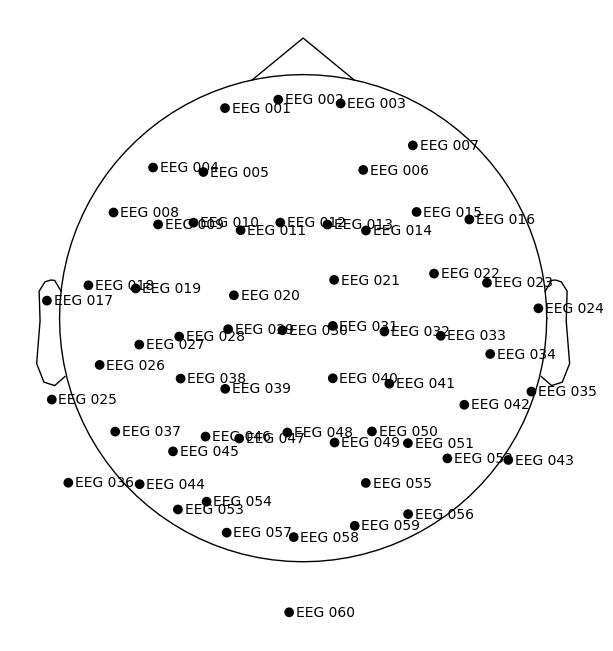

In [8]:
# 1.2 数据可视化探索
print("【步骤 2】数据探索")
print("-" * 40)

# 绘制原始数据（前30秒）
# raw.plot(duration=30, n_channels=40, scalings='auto',
#          title='Raw MEG/EEG Data (First 30 seconds)',
#          block=False)

# 绘制EEG通道位置
montage = raw.get_montage()
if montage:
    montage.plot(kind='topomap', show_names=True)

In [27]:
# 1.3 事件检测
events = mne.find_events(raw, stim_channel='STI 014', verbose=False)
print(events.shape)# (128, 3) # 采样点, 前一个事件ID, 当前事件ID
event_df = pd.DataFrame(events, columns=['sample_point', 'prev_event_id', 'current_event_id'])
print(event_df.head())

print(f"检测到事件总数: {len(events)}")
print(f"\n事件类型分布:")
event_ids, counts = np.unique(events[:, 2], return_counts=True)
print(event_ids)
print(counts)

event_dict = {
    'auditory/left': 1,
    'auditory/right': 2,
    'visual/left': 3,
    'visual/right': 4
}

for label, event_id in event_dict.items():
    # (结果A) if (条件) else (结果B)
    count = (counts[event_ids == event_id][0]) \
            if (event_id in event_ids) \
            else (0)
    print(f"  {label} (ID={event_id}): {count} trials")


(319, 3)
   sample_point  prev_event_id  current_event_id
0          6994              0                 2
1          7086              0                 3
2          7192              0                 1
3          7304              0                 4
4          7413              0                 2
检测到事件总数: 319

事件类型分布:
[ 1  2  3  4  5 32]
[72 73 73 70 15 16]
  auditory/left (ID=1): 72 trials
  auditory/right (ID=2): 73 trials
  visual/left (ID=3): 73 trials
  visual/right (ID=4): 70 trials


### 阶段 2: 数据预处理

In [38]:
# 2.1 选择EEG通道
print("【步骤 3】预处理 - 通道选择")
print("-" * 40)

# 仅保留EEG和相关通道
raw_eeg:mne.io.RawArray = raw.copy().pick_types(eeg=True, stim=True, eog=True)
print(f"选择后通道数: {len(raw_eeg.ch_names)}")
print(f"EEG通道: {len([ch for ch in raw_eeg.ch_names if ch.startswith('EEG')])}")

【步骤 3】预处理 - 通道选择
----------------------------------------
选择后通道数: 69
EEG通道: 59



【步骤 4】预处理 - 滤波
----------------------------------------
带通滤波完成: 0.1-40 Hz


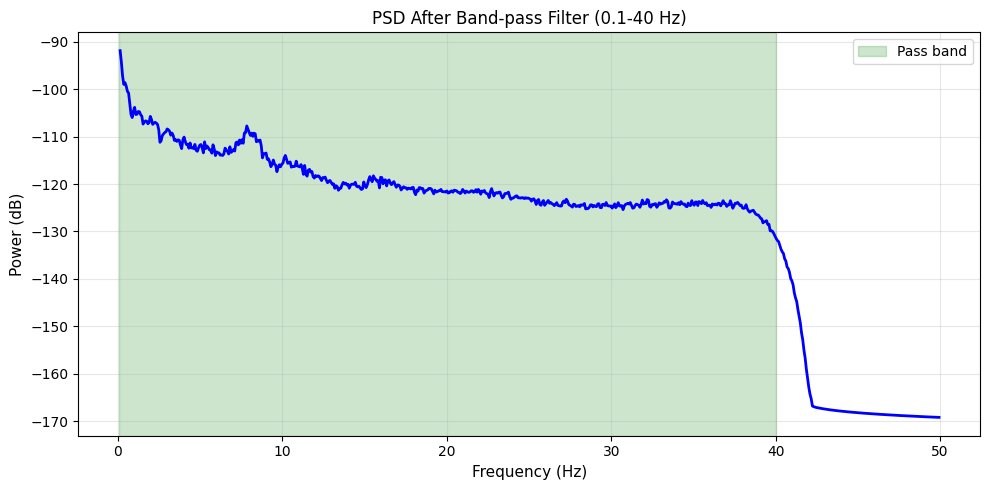

In [ ]:
# 2.2 滤波
print("\n【步骤 4】预处理 - 滤波")
print("-" * 40)

# 带通滤波：0.1-40 Hz
# 适用于ERP分析
raw_eeg.filter(l_freq=0.1, h_freq=40, fir_design='firwin', verbose=False)
print("带通滤波完成: 0.1-40 Hz")

# 显示滤波后的PSD
fig, ax = plt.subplots(figsize=(10, 5))
spectrum = raw_eeg.compute_psd(
    method='welch',
    fmin=0.1,
    fmax=50,
    n_fft=2048,
    verbose=False
) # 默认只计算EEG通道的PSD (EEG通道数, 频率点数)
psds, freqs = spectrum.get_data(return_freqs=True)

psds_eeg = psds # (EEG通道数, 频率点数)
mean_psd = 10 * np.log10(psds_eeg.mean(axis=0)) # (频率点数,)
ax.plot(freqs, mean_psd, color='blue', linewidth=2)
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Power (dB)', fontsize=11)
ax.set_title('PSD After Band-pass Filter (0.1-40 Hz)', fontsize=12)
ax.axvspan(0.1, 40, alpha=0.2, color='green', label='Pass band')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
# 2.3 重参考
print("\n【步骤 5】预处理 - 重参考")
print("-" * 40)
# 数据集中已有平均参考通道,无需设置平均参考
# raw_eeg.set_eeg_reference(ref_channels='average', projection=True, verbose=False)
print(raw_eeg.info['projs'])
print("平均参考设置完成")


【步骤 5】预处理 - 重参考
----------------------------------------
[<Projection | Average EEG reference, active : False, n_channels : 60>]
平均参考设置完成



【步骤 6】预处理 - 坏道检测
----------------------------------------


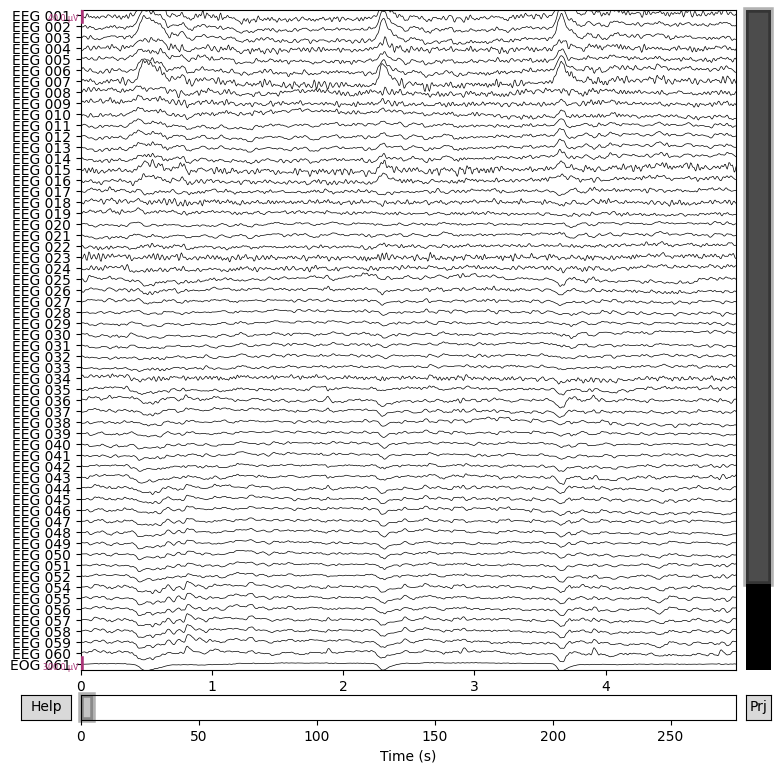

提示: 在可视化窗口中标记坏道后关闭窗口
当前坏道: []

无坏道，跳过插值步骤


In [50]:
# 2.4 坏道检测
print("\n【步骤 6】预处理 - 坏道检测")
print("-" * 40)

# 可视化检测坏道
raw_eeg.plot(duration=5, n_channels=60, title='Bad Channel Detection',
             block=False)
print("提示: 在可视化窗口中标记坏道后关闭窗口")
print(f"当前坏道: {raw_eeg.info['bads']}")

# 如果有坏道，进行插值
if len(raw_eeg.info['bads']) > 0:
    print(f"\n对 {len(raw_eeg.info['bads'])} 个坏道进行插值...")
    raw_eeg.interpolate_bads(reset_bads=True, verbose=False)
    print("坏道插值完成")
else:
    print("\n无坏道，跳过插值步骤")


【步骤 7】预处理 - ICA去伪迹
----------------------------------------
拟合ICA模型...
ICA完成，提取了 20 个成分
检测到的EOG成分: [np.int64(0)]


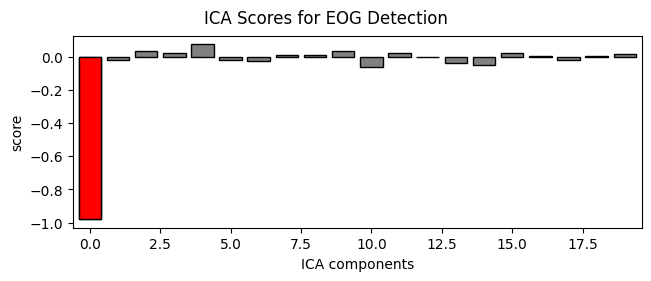

ICA伪迹去除完成


In [67]:
# 2.5 ICA去伪迹
print("\n【步骤 7】预处理 - ICA去伪迹")
print("-" * 40)

# 为ICA创建专用数据副本（需要高通滤波≥1 Hz）
raw_ica = raw_eeg.copy().filter(l_freq=1.0, h_freq=None, verbose=False)
# 此时，raw_ica 包含EEG、EOG、STIM通道
# 配置并运行ICA
ica = ICA(
    n_components=20, 
    method='fastica', 
    max_iter='auto', 
    random_state=42
)

print("拟合ICA模型...")
ica.fit(raw_ica, picks='eeg', verbose=False)
print(f"ICA完成，提取了 {ica.n_components_} 个成分")

# 自动检测EOG相关成分
eog_indices, eog_scores = ica.find_bads_eog(
    raw_ica, 
    # ch_name='EOG 061', 
    verbose=False
)
print(f"检测到的EOG成分: {eog_indices}")
ica.plot_scores(eog_scores, exclude=eog_indices, 
                    title='ICA Scores for EOG Detection')

# 排除伪迹成分
ica.exclude = eog_indices

# 应用ICA
raw_clean = raw_eeg.copy()
ica.apply(raw_clean, verbose=False)
print("ICA伪迹去除完成")

### 阶段 3: Epoch提取与伪迹拒绝

In [68]:
# 3.1 创建Epochs
print("【步骤 8】Epoch提取")
print("-" * 40)

events = mne.find_events(raw_clean, stim_channel='STI 014', verbose=False)

tmin, tmax = -0.2, 0.8
epochs = mne.Epochs(raw_clean, events, event_id=event_dict,
                    tmin=tmin, tmax=tmax,
                    baseline=(-0.2, 0),
                    reject=dict(eeg=150e-6),
                    preload=True, verbose=False)

print(f"总事件数: {len(events)}")
print(f"保留的epochs: {len(epochs)}")
print(f"拒绝的epochs: {len(events) - len(epochs)}")

print(f"\n各条件trial数量:")
for cond in epochs.event_id.keys():
    print(f"  {cond}: {len(epochs[cond])}")

【步骤 8】Epoch提取
----------------------------------------
总事件数: 319
保留的epochs: 286
拒绝的epochs: 33

各条件trial数量:
  auditory/left: 71
  auditory/right: 73
  visual/left: 72
  visual/right: 70


### 阶段 4: ERP分析

【步骤 9】ERP分析 - Evoked计算
----------------------------------------
听觉平均: 144.0 trials
视觉平均: 142.00000000000003 trials


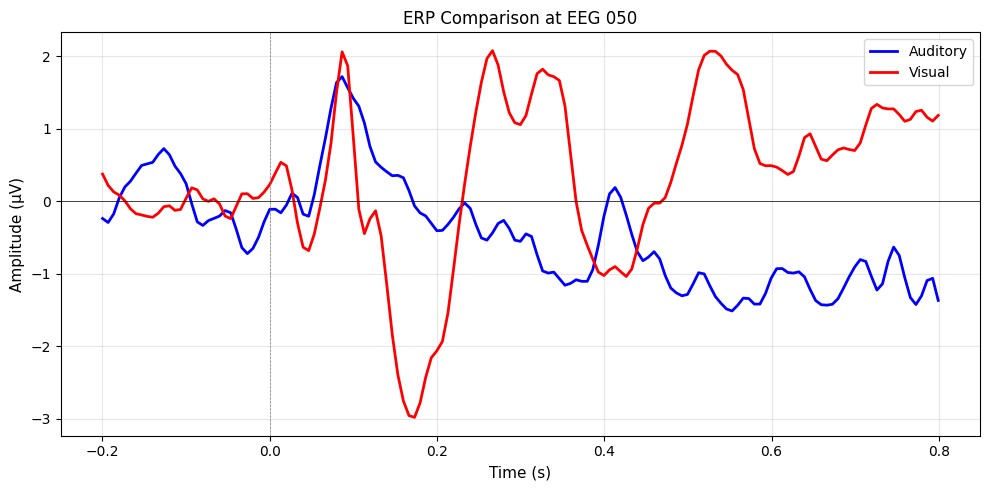

In [75]:
# 4.1 计算Evoked
print("【步骤 9】ERP分析 - Evoked计算")
print("-" * 40)

# 按条件计算平均ERP
evoked_aud_l = epochs['auditory/left'].average() # (59, 151)
evoked_aud_r = epochs['auditory/right'].average() # (59, 151)
evoked_vis_l = epochs['visual/left'].average() # (59, 151)
evoked_vis_r = epochs['visual/right'].average() # (59, 151)

# 合并感觉模态
evoked_aud = mne.combine_evoked([evoked_aud_l, evoked_aud_r], weights='nave') # (59, 151)
evoked_vis = mne.combine_evoked([evoked_vis_l, evoked_vis_r], weights='nave') # (59, 151)


print(f"听觉平均: {evoked_aud.nave} trials")
print(f"视觉平均: {evoked_vis.nave} trials")

# 绘制ERP对比
fig, ax = plt.subplots(figsize=(10, 5))
ch_pick = 'EEG 050'
ch_idx = evoked_aud.ch_names.index(ch_pick)

ax.plot(evoked_aud.times, evoked_aud.data[ch_idx] * 1e6, 
        'b-', linewidth=2, label='Auditory')
ax.plot(evoked_vis.times, evoked_vis.data[ch_idx] * 1e6, 
        'r-', linewidth=2, label='Visual')

ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('Amplitude (μV)', fontsize=11)
ax.set_title(f'ERP Comparison at {ch_pick}', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


【步骤 10】ERP分析 - Joint Plot
----------------------------------------


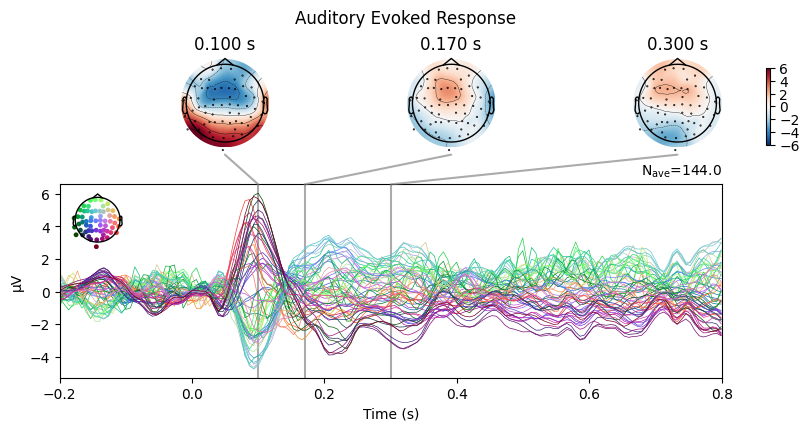

In [76]:
# 4.2 Joint Plot可视化
print("\n【步骤 10】ERP分析 - Joint Plot")
print("-" * 40)

evoked_aud.plot_joint(times=[0.1, 0.17, 0.3],
                      title='Auditory Evoked Response',
                      ts_args={'xlim': [-0.2, 0.8]})
plt.show()

In [91]:
# 4.3 ERP成分测量
print("\n【步骤 11】ERP分析 - 成分测量")
print("-" * 40)

def measure_component(evoked, ch_name, t_window, name):
    ch_idx = evoked.ch_names.index(ch_name)
    tmask = (evoked.times >= t_window[0]) & (evoked.times <= t_window[1])
    data = evoked.data[ch_idx, tmask] * 1e6
    times = evoked.times[tmask]
    peak_idx = np.argmax(np.abs(data)) # 找到绝对值(峰值)最大的索引
    return {
        'name': name,
        'amplitude': data[peak_idx],
        'latency': times[peak_idx] * 1000
    }

ch_target = 'EEG 050'
components_to_measure = [
    ('P1', (0.05, 0.12)),
    ('N1', (0.10, 0.18)),
    ('P2', (0.15, 0.22)),
    ('P3', (0.25, 0.45))
]

print(f"\nERP成分测量 - 通道: {ch_target}")
print(f"{'成分':<8} {'听觉幅度(μV)':<16} {'听觉潜伏期(ms)':<18} "
      f"{'视觉幅度(μV)':<16} {'视觉潜伏期(ms)':<16}")
print("-" * 74)

results = {}
for comp_name, t_win in components_to_measure:
    aud_res = measure_component(evoked_aud, ch_target, t_win, comp_name)
    vis_res = measure_component(evoked_vis, ch_target, t_win, comp_name)
    results[comp_name] = {'auditory': aud_res, 'visual': vis_res}
    print(f"{comp_name:<8} {aud_res['amplitude']:>12.2f}      "
          f"{aud_res['latency']:>10.1f}      "
          f"{vis_res['amplitude']:>12.2f}      "
          f"{vis_res['latency']:>10.1f}")


【步骤 11】ERP分析 - 成分测量
----------------------------------------

ERP成分测量 - 通道: EEG 050
成分       听觉幅度(μV)         听觉潜伏期(ms)          视觉幅度(μV)         视觉潜伏期(ms)       
--------------------------------------------------------------------------
P1               1.72            86.6              2.06            86.6
N1               1.31           106.6             -2.98           173.2
P2              -0.40           199.8             -2.98           173.2
P3              -1.16           353.0              2.08           266.4



【步骤 12】ERP分析 - 统计检验
----------------------------------------
(144, 69, 151)
(144, 30)

P3窗口 (300-500 ms) 统计检验
通道: EEG 050
听觉平均: -0.77 μV (SD=3.64)
视觉平均: 0.21 μV (SD=3.77)
t(141) = -2.090, p = 0.0384
显著性: *


C:\Users\15221\AppData\Local\Temp\ipykernel_31100\2253518146.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([aud_amps, vis_amps], labels=['Auditory', 'Visual'],


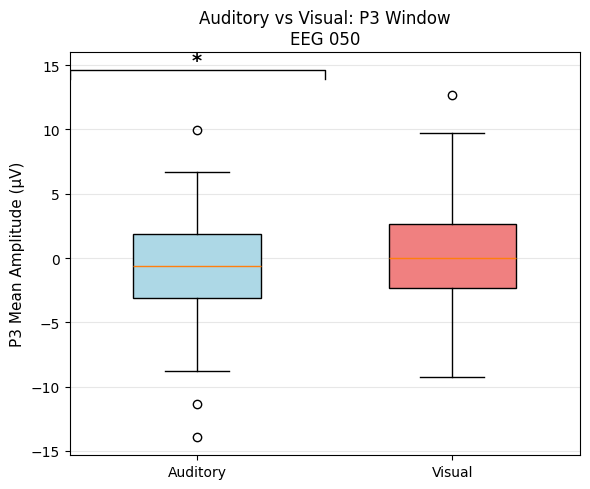

In [ ]:
# 4.4 统计分析
print("\n【步骤 12】ERP分析 - 统计检验")
print("-" * 40)

p3_window = (0.3, 0.5)
tmin_idx = np.searchsorted(epochs.times, p3_window[0]) # 找到第一个大于等于p3_window[0]的索引
tmax_idx = np.searchsorted(epochs.times, p3_window[1]) # 找到第一个大于p3_window[1]的索引
ch_idx = epochs.ch_names.index(ch_target)

print(epochs['auditory'].get_data().shape)
print(epochs['auditory'].get_data()[:, ch_idx, tmin_idx:tmax_idx].shape)

# (n_trials, n_times) -> (n_trials,)
# 计算每个试次的平均时间ERP
aud_amps = np.mean(epochs['auditory'].get_data()[:, ch_idx, tmin_idx:tmax_idx], axis=1) * 1e6
vis_amps = np.mean(epochs['visual'].get_data()[:, ch_idx, tmin_idx:tmax_idx], axis=1) * 1e6

min_n = min(len(aud_amps), len(vis_amps))
t_stat, p_value = stats.ttest_rel(aud_amps[:min_n], vis_amps[:min_n]) # T检验: 对比听觉和视觉ERP的显著性

print(f"\nP3窗口 ({p3_window[0]*1000:.0f}-{p3_window[1]*1000:.0f} ms) 统计检验")
print(f"通道: {ch_target}")
print(f"听觉平均: {np.mean(aud_amps):.2f} μV (SD={np.std(aud_amps):.2f})")
print(f"视觉平均: {np.mean(vis_amps):.2f} μV (SD={np.std(vis_amps):.2f})")
print(f"t({min_n-1}) = {t_stat:.3f}, p = {p_value:.4f}")

sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "n.s."
print(f"显著性: {sig}")

# 可视化统计结果
fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot([aud_amps, vis_amps], labels=['Auditory', 'Visual'],
                patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral']):
    patch.set_facecolor(color)
ax.set_ylabel(f'P3 Mean Amplitude (μV)', fontsize=11)
ax.set_title(f'Auditory vs Visual: P3 Window\n{ch_target}', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

y_max = max(np.max(aud_amps), np.max(vis_amps))
ax.plot([0.5, 0.5, 1.5, 1.5], [y_max*1.1, y_max*1.15, y_max*1.15, y_max*1.1],
        color='black', linewidth=1)
ax.text(1, y_max*1.18, sig, ha='center', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 阶段 5: 时频分析

In [94]:
# 5.1 重新创建适合时频分析的epochs
print("【步骤 13】时频分析 - 数据准备")
print("-" * 40)

events = mne.find_events(raw_clean, stim_channel='STI 014', verbose=False)
epochs_tf = mne.Epochs(raw_clean, events, event_id=event_dict,
                       tmin=-1.0, tmax=1.0,
                       baseline=None,
                       reject=dict(eeg=150e-6),
                       preload=True, verbose=False)

epochs_tf_aud = epochs_tf['auditory'].copy()
print(f"时频分析epochs: {len(epochs_tf_aud)} trials")
print(f"时间窗口: [{epochs_tf_aud.tmin}, {epochs_tf_aud.tmax}] s")

【步骤 13】时频分析 - 数据准备
----------------------------------------
时频分析epochs: 142 trials
时间窗口: [-0.9989760657919393, 0.9989760657919393] s


In [95]:
# 5.2 Morlet小波时频分析
print("\n【步骤 14】时频分析 - Morlet小波变换")
print("-" * 40)

freqs = np.arange(3, 40, 2) # 3 5 7 9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41Hz
n_cycles = freqs / 2.0 # 1.5 2.0 2.5 3.0 3.5 4.0 4.5 5.0 5.5 6.0 6.5 7.0 7.5 8.0 8.5 9.0 9.5 10.0

print(f"频率范围: {freqs[0]}-{freqs[-1]} Hz")
print("正在计算时频变换...")

power = tfr_morlet(epochs_tf_aud, freqs=freqs, n_cycles=n_cycles,
                   use_fft=True, return_itc=False, average=True, verbose=False)

# 基线校正
power.apply_baseline(baseline=(-0.5, -0.1), mode='logratio')
print("时频计算与基线校正完成")


【步骤 14】时频分析 - Morlet小波变换
----------------------------------------
频率范围: 3-39 Hz
正在计算时频变换...
时频计算与基线校正完成



【步骤 15】时频分析 - 可视化
----------------------------------------
时频数据形状: (59, 19, 301)


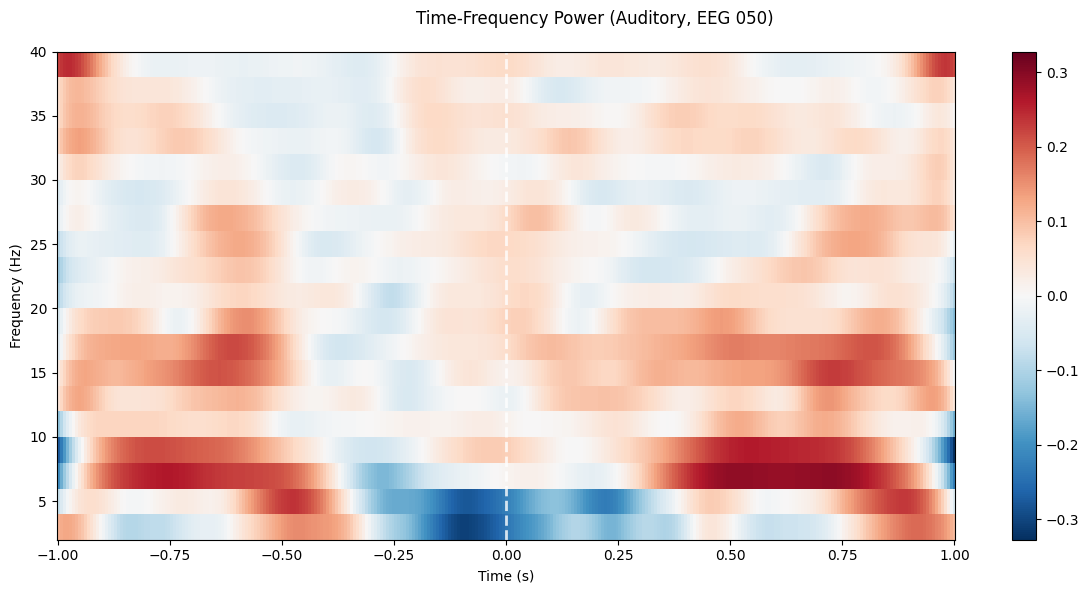

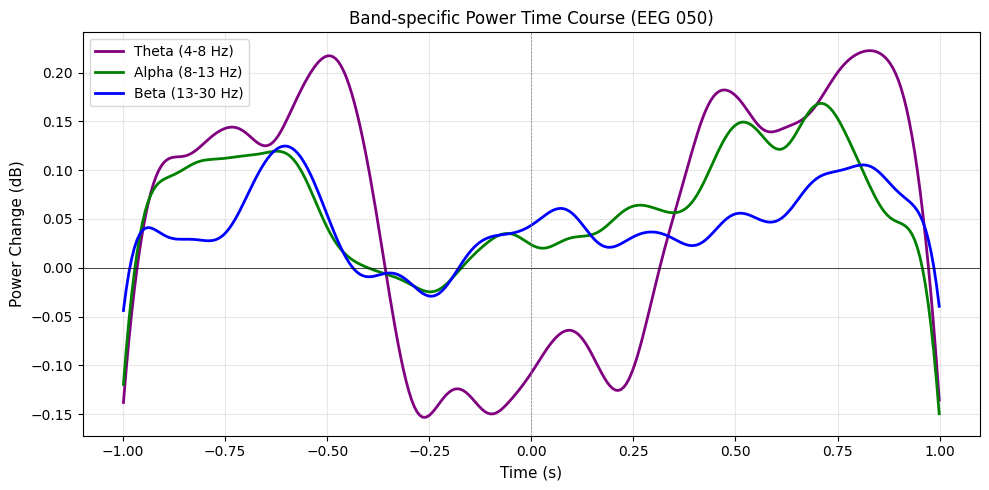

In [102]:
# 5.3 时频可视化
print("\n【步骤 15】时频分析 - 可视化")
print("-" * 40)

print(f"时频数据形状: {power.shape}")

ch_tf = 'EEG 050'
ch_tf_idx = power.ch_names.index(ch_tf)

# 时频图
fig, ax = plt.subplots(figsize=(12, 6))
power.plot(picks=[ch_tf_idx], show=False, axes=ax, cmap='RdBu_r',
           colorbar=True,
           title=f'Time-Frequency Power (Auditory, {ch_tf})')
ax.axvline(0, color='white', linestyle='--', linewidth=2, alpha=0.8)
plt.tight_layout()
plt.show()

# 频段时程
fig, ax = plt.subplots(figsize=(10, 5))
bands = {'Theta': (4, 8), 'Alpha': (8, 13), 'Beta': (13, 30)}
colors = {'Theta': 'purple', 'Alpha': 'green', 'Beta': 'blue'}


for band, (fmin, fmax) in bands.items():
    fmask = (freqs >= fmin) & (freqs <= fmax)
    # 尺度平均功率 (Scale-Averaged Power)：这是最学术的叫法。在小波分析中，“频率”通常对应“尺度”（Scale）。将特定尺度范围内的能量进行平均，就叫尺度平均功率。
    # 频带平均时间序列 (Band-Averaged Time Series)：这是更直观的叫法。因为你固定了频率范围（fmask），对频率轴进行了压缩，最终得到的是一个随时间变化的一维曲线。
    band_ts = np.mean(power.data[ch_tf_idx, fmask, :], axis=0) # 最后只剩时间维度
    ax.plot(power.times, band_ts, color=colors[band], linewidth=2,
            label=f'{band} ({fmin}-{fmax} Hz)')

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('Power Change (dB)', fontsize=11)
ax.set_title(f'Band-specific Power Time Course ({ch_tf})', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 阶段 6: 综合报告

In [103]:
# 6.1 生成完整分析报告
print("\n" + "=" * 60)
print("完 整 分 析 报 告")
print("=" * 60)

print("\n【数据集信息】")
print(f"- 数据文件: {raw_fname.name}")
print(f"- 采样率: {raw.info['sfreq']} Hz")
print(f"- 记录时长: {raw.times[-1]:.1f} 秒")
print(f"- EEG通道数: {len([ch for ch in raw_eeg.ch_names if ch.startswith('EEG')])}")

print("\n【预处理参数】")
print(f"- 带通滤波: 0.1-40 Hz (FIR)")
print(f"- 参考方式: 平均参考")
print(f"- ICA成分数: {ica.n_components_}")
print(f"- 排除的ICA成分: {ica.exclude}")
print(f"- Epoch窗口: [{tmin}, {tmax}] s")
print(f"- 基线窗口: [{tmin}, 0] s")
print(f"- 幅度拒绝阈值: ±150 μV")

print("\n【Trial统计】")
print(f"- 总事件数: {len(events)}")
print(f"- 保留epochs: {len(epochs)}")
for cond in epochs.event_id.keys():
    print(f"  {cond}: {len(epochs[cond])} trials")

print("\n【ERP分析结果】")
print(f"目标通道: {ch_target}")
for comp_name in components_to_measure:
    comp = comp_name[0] # 取第一个元素，即通道名称，第二个元素是频率范围
    aud = results[comp]['auditory']
    vis = results[comp]['visual']
    print(f"  {comp}: 听觉 {aud['amplitude']:.2f} μV @ {aud['latency']:.0f} ms | "
          f"视觉 {vis['amplitude']:.2f} μV @ {vis['latency']:.0f} ms")

print(f"\n【统计检验结果】")
print(f"- P3窗口: {p3_window[0]*1000:.0f}-{p3_window[1]*1000:.0f} ms")
print(f"- t({min_n-1}) = {t_stat:.3f}, p = {p_value:.4f} {sig}")

print("\n【时频分析参数】")
print(f"- 方法: Morlet小波变换")
print(f"- 频率范围: {freqs[0]}-{freqs[-1]} Hz ({len(freqs)} points)")
print(f"- 周期数: {n_cycles[0]:.1f}-{n_cycles[-1]:.1f}")
print(f"- 基线校正: logratio, window=(-0.5, -0.1) s")

print("\n" + "=" * 60)
print("分析完成!")
print("=" * 60)


完 整 分 析 报 告

【数据集信息】
- 数据文件: sample_audvis_filt-0-40_raw.fif
- 采样率: 150.15374755859375 Hz
- 记录时长: 277.7 秒
- EEG通道数: 59

【预处理参数】
- 带通滤波: 0.1-40 Hz (FIR)
- 参考方式: 平均参考
- ICA成分数: 20
- 排除的ICA成分: [np.int64(0)]
- Epoch窗口: [-0.2, 0.8] s
- 基线窗口: [-0.2, 0] s
- 幅度拒绝阈值: ±150 μV

【Trial统计】
- 总事件数: 319
- 保留epochs: 286
  auditory/left: 71 trials
  auditory/right: 73 trials
  visual/left: 72 trials
  visual/right: 70 trials

【ERP分析结果】
目标通道: EEG 050
  P1: 听觉 1.72 μV @ 87 ms | 视觉 2.06 μV @ 87 ms
  N1: 听觉 1.31 μV @ 107 ms | 视觉 -2.98 μV @ 173 ms
  P2: 听觉 -0.40 μV @ 200 ms | 视觉 -2.98 μV @ 173 ms
  P3: 听觉 -1.16 μV @ 353 ms | 视觉 2.08 μV @ 266 ms

【统计检验结果】
- P3窗口: 300-500 ms
- t(141) = -2.090, p = 0.0384 *

【时频分析参数】
- 方法: Morlet小波变换
- 频率范围: 3-39 Hz (19 points)
- 周期数: 1.5-19.5
- 基线校正: logratio, window=(-0.5, -0.1) s

分析完成!


In [106]:
# 6.2 保存结果
print("\n【步骤 17】保存结果")
print("-" * 40)

outputs_dir = os.path.abspath("../outputs")
os.makedirs(outputs_dir, exist_ok=True)

# 保存预处理后的epochs
epochs.save(os.path.join(outputs_dir, 'final_epochs-epo.fif'), overwrite=True)
print(f"Epochs保存: final_epochs-epo.fif")

# 保存Evoked数据
evoked_aud.save(os.path.join(outputs_dir, 'auditory-evoked-ave.fif'), overwrite=True)
evoked_vis.save(os.path.join(outputs_dir, 'visual-evoked-ave.fif'), overwrite=True)
print(f"Evoked保存: auditory-evoked-ave.fif, visual-evoked-ave.fif")

# 保存时频数据
power.save(os.path.join(outputs_dir, "tfr_power-tfr.hdf5"), overwrite=True)
print(f"时频数据保存: tfr_power-tfr.hdf5")

print("\n所有结果已保存!")


【步骤 17】保存结果
----------------------------------------
Epochs保存: final_epochs-epo.fif
Evoked保存: auditory-evoked-ave.fif, visual-evoked-ave.fif


C:\Users\15221\AppData\Local\Temp\ipykernel_31100\2023024724.py:14: RuntimeWarning: converting "nave" to integer before saving evoked; this can have a minor effect on the scale of source estimates that are computed using "nave".
  evoked_vis.save(os.path.join(outputs_dir, 'visual-evoked-ave.fif'), overwrite=True)


时频数据保存: tfr_power-tfr.hdf5

所有结果已保存!


## 单元小结

**完整流程回顾：**
1. **数据加载与探索**：了解数据结构和质量
2. **预处理**：滤波、重参考、坏道处理、ICA去伪迹
3. **Epoch提取**：事件分段、基线校正、伪迹拒绝
4. **ERP分析**：Evoked计算、成分测量、统计检验
5. **时频分析**：Morlet小波、基线校正、ERS/ERD
6. **结果报告**：整合所有分析结果

**关键学习点：**
- 预处理是后续分析的基础，每一步都需谨慎
- ERP和时频分析提供互补的信息
- 统计分析应考虑多重比较问题
- 结果的可重现性需要良好的代码管理和参数记录

**进一步学习建议：**
- 尝试使用BIDS格式组织数据
- 探索源定位分析（Source Localization）
- 学习多受试者组水平的统计分析
- 尝试连接分析（Connectivity Analysis）
- 使用MNE-BIDS进行数据共享